# Notebook 14: Proximal Policy Optimization (PPO)

**Series:** Reinforcement Learning Basics (14/20)

---

## 1. The Core Problem

Policy gradient methods are sensitive to step size:
- **Too large** → policy collapses (catastrophic performance drop)
- **Too small** → painfully slow learning

**PPO** constrains how much the policy can change per update.

## 2. Probability Ratio

$$r_t(\theta) = \frac{\pi_\theta(a_t|s_t)}{\pi_{\theta_{old}}(a_t|s_t)}$$

- $r_t = 1$ when new and old policies agree
- $r_t > 1$ means new policy gives higher probability to $a_t$

## 3. PPO-Clip Objective

$$L^{CLIP}(\theta) = \mathbb{E}_t \left[ \min\Big( r_t(\theta) \hat{A}_t, \; \text{clip}(r_t(\theta), 1-\varepsilon, 1+\varepsilon) \hat{A}_t \Big) \right]$$

**How clipping works:**
- When $\hat{A}_t > 0$ (good action): caps the benefit at $r_t = 1 + \varepsilon$
- When $\hat{A}_t < 0$ (bad action): caps the benefit at $r_t = 1 - \varepsilon$

## 4. Full PPO Objective

$$L(\theta) = L^{CLIP}(\theta) - c_1 L^{VF}(\theta) + c_2 H[\pi_\theta]$$

| Term | Purpose |
|------|---------|
| $L^{CLIP}$ | Clipped policy gradient |
| $L^{VF} = (V_\theta(s_t) - V_t^{target})^2$ | Value function accuracy |
| $H[\pi_\theta]$ | Entropy bonus for exploration |

## 5. PPO Algorithm

1. Collect trajectories with current policy $\pi_{\theta_{old}}$
2. Compute advantages using GAE
3. For $K$ epochs:
   - Sample minibatches from collected data
   - Compute clipped objective and update $\theta$
4. $\theta_{old} \leftarrow \theta$, repeat

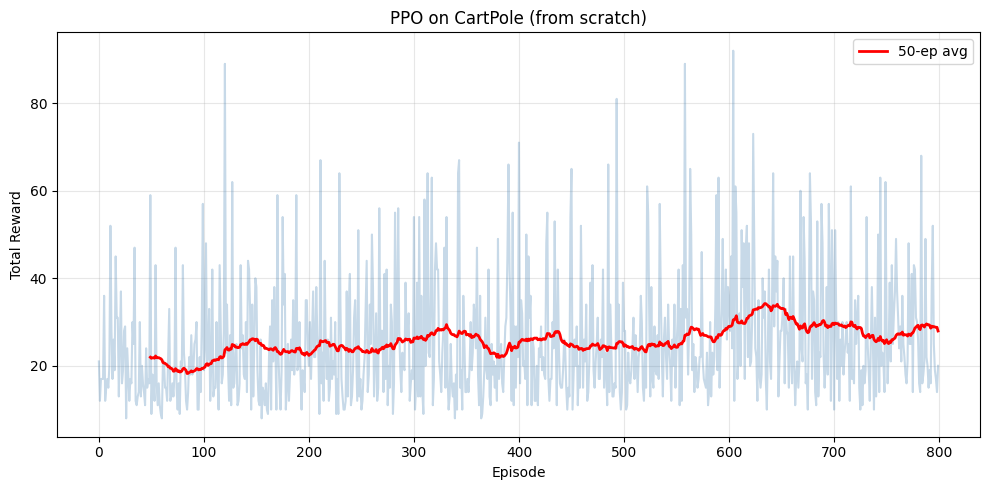

Last 100 avg: 26.8


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# CartPole environment (reused)
class CartPole:
    def __init__(self):
        self.gravity = 9.8; self.masscart = 1.0; self.masspole = 0.1
        self.total_mass = 1.1; self.length = 0.5; self.polemass_length = 0.05
        self.force_mag = 10.0; self.tau = 0.02
        self.theta_threshold = 12*np.pi/180; self.x_threshold = 2.4
    def reset(self):
        self.state = np.random.uniform(-0.05, 0.05, 4); return self.state.copy()
    def step(self, action):
        x,xd,th,thd = self.state; f = self.force_mag if action==1 else -self.force_mag
        ct,st = np.cos(th),np.sin(th)
        tmp = (f+self.polemass_length*thd**2*st)/self.total_mass
        thacc = (self.gravity*st-ct*tmp)/(self.length*(4/3-self.masspole*ct**2/self.total_mass))
        xacc = tmp - self.polemass_length*thacc*ct/self.total_mass
        self.state = np.array([x+self.tau*xd,xd+self.tau*xacc,th+self.tau*thd,thd+self.tau*thacc])
        done = abs(self.state[0])>self.x_threshold or abs(self.state[2])>self.theta_threshold
        return self.state.copy(), 1.0 if not done else 0.0, done

def softmax(logits):
    e = np.exp(logits - np.max(logits))
    return e / e.sum()

def compute_gae(rewards, values, gamma=0.99, lam=0.95):
    T = len(rewards)
    advantages = np.zeros(T)
    last_gae = 0
    for t in reversed(range(T)):
        next_val = 0 if t == T-1 else values[t+1]
        delta = rewards[t] + gamma * next_val - values[t]
        advantages[t] = last_gae = delta + gamma * lam * last_gae
    return advantages, advantages + np.array(values)

# ============================================
# PPO Implementation
# ============================================
class PPO:
    def __init__(self, lr_actor=0.003, lr_critic=0.01, clip_eps=0.2, gamma=0.99, lam=0.95, epochs=4):
        self.theta = np.zeros((4, 2))
        self.w = np.zeros(4)
        self.lr_actor = lr_actor
        self.lr_critic = lr_critic
        self.clip_eps = clip_eps
        self.gamma = gamma
        self.lam = lam
        self.epochs = epochs

    def get_action_and_prob(self, state):
        probs = softmax(state @ self.theta)
        action = np.random.choice(2, p=probs)
        return action, probs[action]

    def train(self, states, actions, old_probs, advantages, returns):
        # Normalize advantages
        advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

        for _ in range(self.epochs):
            for i in range(len(states)):
                s, a = states[i], actions[i]
                probs = softmax(s @ self.theta)
                ratio = probs[a] / (old_probs[i] + 1e-8)

                # Clipped objective
                adv = advantages[i]
                surr1 = ratio * adv
                surr2 = np.clip(ratio, 1 - self.clip_eps, 1 + self.clip_eps) * adv
                policy_loss = -min(surr1, surr2)

                # Actor gradient (approximate)
                grad_log = -probs.copy()
                grad_log[a] += 1
                if surr1 < surr2:
                    self.theta -= self.lr_actor * policy_loss * np.outer(s, grad_log) / len(states)
                else:
                    clipped_grad = np.clip(ratio, 1-self.clip_eps, 1+self.clip_eps)
                    self.theta += self.lr_actor * adv * np.outer(s, grad_log) / len(states)

                # Critic update
                v_pred = s @ self.w
                critic_loss = returns[i] - v_pred
                self.w += self.lr_critic * critic_loss * s / len(states)

# Train PPO
env = CartPole()
ppo = PPO()
episode_rewards = []

for ep in range(800):
    state = env.reset()
    states, actions, rewards, old_probs = [], [], [], []

    for _ in range(500):
        action, prob = ppo.get_action_and_prob(state)
        next_state, reward, done = env.step(action)
        states.append(state)
        actions.append(action)
        rewards.append(reward)
        old_probs.append(prob)
        state = next_state
        if done: break

    values = [s @ ppo.w for s in states]
    advantages, returns = compute_gae(rewards, values, ppo.gamma, ppo.lam)

    ppo.train(states, actions, old_probs, advantages, returns)
    episode_rewards.append(sum(rewards))

plt.figure(figsize=(10, 5))
plt.plot(episode_rewards, alpha=0.3, color='steelblue')
w = 50
sm = np.convolve(episode_rewards, np.ones(w)/w, mode='valid')
plt.plot(range(w-1, len(episode_rewards)), sm, 'r-', linewidth=2, label=f'{w}-ep avg')
plt.xlabel('Episode'); plt.ylabel('Total Reward')
plt.title('PPO on CartPole (from scratch)')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
plt.show()
print(f"Last 100 avg: {np.mean(episode_rewards[-100:]):.1f}")

## Summary

| Component | Formula |
|-----------|---------|
| **Ratio** | $r_t(\theta) = \pi_\theta(a_t|s_t) / \pi_{\theta_{old}}(a_t|s_t)$ |
| **PPO-Clip** | $\min(r_t \hat{A}_t, \text{clip}(r_t, 1\pm\varepsilon) \hat{A}_t)$ |
| **Full Objective** | $L^{CLIP} - c_1 L^{VF} + c_2 H$ |

**Next:** Notebook 15 — Deep Q-Networks